In [ ]:
# ── Installations ─────────────────────────────────────────────────────────────
!pip install ultralytics huggingface_hub lxml -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2, json, os, torch, numpy as np, gc
from pathlib import Path
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from ultralytics import YOLO
from huggingface_hub import hf_hub_download
from lxml import etree

# ── GPU ───────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")

# ── 1. Charger YOLO ───────────────────────────────────────────────────────────
print("\nChargement YOLO...")
model_path_yolo = hf_hub_download(
    repo_id="biglam/medieval-manuscript-yolov11",
    filename="medieval-yolov11n.pt"
)
model_yolo = YOLO(model_path_yolo)
print("✅ YOLO chargé")

# ── 2. Charger TrOCR fine-tuné ────────────────────────────────────────────────
print("\nChargement TrOCR fine-tuné...")
chemin_modele = "/content/drive/MyDrive/projet_HTR/modele_trocr_medieval"
assert os.path.exists(chemin_modele), (
    f"❌ Dossier introuvable : {chemin_modele}\n"
    f"   As-tu bien exécuté drive.mount('/content/drive') avant cette cellule ?"
)
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model_trocr = VisionEncoderDecoderModel.from_pretrained(
    chemin_modele,
    local_files_only=True
)
model_trocr = model_trocr.to(device)
model_trocr.eval()
print("✅ TrOCR chargé")

# ── 3. Mapping classes YOLO ───────────────────────────────────────────────────
MAPPING_CLASSES = {
    'MainZone'        : 'texte',
    'MarginTextZone'  : 'marge',
    'GraphicZone'     : 'illustration',
    'DropCapitalZone' : 'illustration',
    'RunningTitleZone': 'texte',
    'NumberingZone'   : 'marge',
    'QuireMarksZone'  : 'marge',
}

# ── 4. Fonctions ──────────────────────────────────────────────────────────────
def detecter_zones_yolo(img_path, conf=0.3):
    img = cv2.imread(img_path)
    if img is None:
        return None

    h_orig, w_orig = img.shape[:2]
    results = model_yolo.predict(img_path, conf=conf, verbose=False)
    result  = results[0]

    regions = {'texte': [], 'illustration': [], 'marge': []}

    if result.boxes is not None:
        for box in result.boxes:
            x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
            class_id   = int(box.cls[0])
            class_name = result.names[class_id]
            categorie  = MAPPING_CLASSES.get(class_name, 'texte')
            regions[categorie].append({
                'bbox'      : [x1, y1, x2 - x1, y2 - y1],
                'class_name': class_name,
                'confidence': round(float(box.conf[0]), 4),
            })

    def ordre_lecture(r):
        x, y, bw, bh = r['bbox']
        return (0 if x < w_orig // 2 else 1, y)

    regions['texte'] = sorted(regions['texte'], key=ordre_lecture)
    regions['meta']  = {
        'image'          : str(img_path),
        'largeur'        : w_orig,
        'hauteur'        : h_orig,
        'nb_texte'       : len(regions['texte']),
        'nb_illustration': len(regions['illustration']),
        'nb_marge'       : len(regions['marge']),
        'modele_layout'  : 'biglam/medieval-manuscript-yolov11n',
    }
    return regions


def extraire_region(img_path, bbox, marge=5):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    x, y, bw, bh = bbox
    x_min = max(0, x - marge)
    y_min = max(0, y - marge)
    x_max = min(img.shape[1], x + bw + marge)
    y_max = min(img.shape[0], y + bh + marge)

    region = img[y_min:y_max, x_min:x_max]
    if region.size == 0:
        return None

    h, w   = region.shape
    ratio  = 64 / max(h, 1)
    new_w  = min(int(w * ratio), 960)
    region = cv2.resize(region, (max(new_w, 1), 64))

    return Image.fromarray(region).convert('RGB')


def transcrire_avec_confiance(img_pil):
    """
    Transcrit une image de région avec TrOCR fine-tuné et calcule
    une vraie confiance de ligne à partir des probabilités de génération.
    """
    pixel_values = processor(img_pil, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        outputs = model_trocr.generate(
            pixel_values,
            max_new_tokens=128,
            output_scores=True,
            return_dict_in_generate=True,
        )

    texte = processor.batch_decode(outputs.sequences, skip_special_tokens=True)[0]

    token_ids = outputs.sequences[0][1:]
    probs_par_token = []

    for i, logits in enumerate(outputs.scores):
        if i >= len(token_ids):
            break
        token_id = token_ids[i].item()
        if token_id == processor.tokenizer.pad_token_id:
            continue
        prob = torch.softmax(logits[0], dim=-1)[token_id].item()
        probs_par_token.append(prob)

    if probs_par_token:
        confidence = float(np.exp(np.mean(np.log(np.clip(probs_par_token, 1e-9, 1.0)))))
    else:
        confidence = 0.0

    return texte, confidence, probs_par_token


def bbox_vers_points_xml(x, y, bw, bh):
    return f"{x},{y} {x+bw},{y} {x+bw},{y+bh} {x},{y+bh}"


def exporter_page_xml(nom, img_path, transcriptions, w_orig, h_orig, output_dir):
    NS    = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2019-07-15"
    NSMAP = {None: NS}

    root     = etree.Element("PcGts", nsmap=NSMAP)
    metadata = etree.SubElement(root, "Metadata")
    etree.SubElement(metadata, "Creator").text = "HTR Pipeline HETIC MD5 2026"
    etree.SubElement(metadata, "Created").text  = "2026-06-18"

    page = etree.SubElement(root, "Page")
    page.set("imageFilename", Path(img_path).name)
    page.set("imageWidth",    str(w_orig))
    page.set("imageHeight",   str(h_orig))

    text_region = etree.SubElement(page, "TextRegion")
    text_region.set("id",   f"r_{nom}")
    text_region.set("type", "paragraph")
    etree.SubElement(text_region, "Coords").set(
        "points", f"0,0 {w_orig},0 {w_orig},{h_orig} 0,{h_orig}"
    )

    for t in transcriptions:
        text_line = etree.SubElement(text_region, "TextLine")
        text_line.set("id",     f"l_{nom}_{t['zone_id']:04d}")
        text_line.set("custom", f"confidence:{t['confidence']:.4f}")

        etree.SubElement(text_line, "Coords").set(
            "points", bbox_vers_points_xml(*t['bbox'])
        )
        text_equiv = etree.SubElement(text_line, "TextEquiv")
        text_equiv.set("conf", f"{t['confidence']:.4f}")
        etree.SubElement(text_equiv, "Unicode").text = t['texte']

    out_path = os.path.join(output_dir, f"{nom}.xml")
    etree.ElementTree(root).write(
        out_path, pretty_print=True,
        xml_declaration=True, encoding="UTF-8"
    )
    return out_path


# ── 5. Pipeline principal ─────────────────────────────────────────────────────
output_xml_dir  = "/content/drive/MyDrive/projet_HTR/page_xml"
output_json_dir = "/content/drive/MyDrive/projet_HTR"
os.makedirs(output_xml_dir, exist_ok=True)

images_cibles = [
    "/content/drive/MyDrive/projet_HTR/gallica_v2/images_originales/btv1b55013464t_f141.jpg",
    "/content/drive/MyDrive/projet_HTR/gallica_v2/images_originales/btv1b55013464t_f143.jpg",
]

tous_resultats = []

for img_path in images_cibles:
    nom = Path(img_path).stem

    if not os.path.exists(img_path):
        print(f"❌ Image non trouvée : {img_path}")
        continue

    print(f"\n{'='*50}")
    print(f"📄 Traitement : {nom}")

    print("  [1/3] Détection layout YOLO...")
    regions = detecter_zones_yolo(img_path)
    if not regions:
        print("  ❌ Échec YOLO")
        continue

    zones_texte = regions['texte']
    zones_a_transcrire = [z for z in zones_texte if z.get('class_name') != 'MainZone']
    print(f"  ✅ {len(zones_texte)} zones texte ({len(zones_a_transcrire)} lignes à transcrire) | "
          f"{regions['meta']['nb_illustration']} illus | "
          f"{regions['meta']['nb_marge']} marges")

    print("  [2/3] Transcription TrOCR...")
    transcriptions = []

    for i, zone in enumerate(zones_a_transcrire):
        x, y, bw, bh = zone['bbox']

        img_pil = extraire_region(img_path, [x, y, bw, bh])
        if img_pil is None:
            continue

        try:
            texte, confidence, char_confidences = transcrire_avec_confiance(img_pil)
        except Exception as e:
            texte, confidence, char_confidences = "", 0.0, []

        transcriptions.append({
            'zone_id'         : i,
            'bbox'            : [x, y, bw, bh],
            'class_name'      : zone.get('class_name', 'DefaultLine'),
            'texte'           : texte,
            'confidence'      : confidence,
            'char_confidences': char_confidences,
            'needs_review'    : confidence < 0.75 or len(texte.strip()) < 3,
        })

        print(f"    zone {i+1:02d}/{len(zones_a_transcrire)} : \"{texte[:60]}\" (conf={confidence:.3f})")

        del img_pil
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f"  ✅ {len(transcriptions)} zones transcrites")

    print("  [3/3] Export PAGE XML...")
    w_orig = regions['meta']['largeur']
    h_orig = regions['meta']['hauteur']

    xml_path = exporter_page_xml(
        nom, img_path, transcriptions,
        w_orig, h_orig, output_xml_dir
    )
    print(f"  ✅ XML sauvegardé : {xml_path}")

    tous_resultats.append({
        'image'          : img_path,
        'nb_zones'       : len(transcriptions),
        'transcriptions' : transcriptions,
        'meta_layout'    : regions['meta'],
    })

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ── 6. Sauvegarder JSON global ────────────────────────────────────────────────
output_json = os.path.join(output_json_dir, "transcriptions_nouvelles_images.json")
with open(output_json, 'w', encoding='utf-8') as f:
    json.dump(tous_resultats, f, ensure_ascii=False, indent=2)

print(f"\n{'='*50}")
print(f"✅ Pipeline terminé !")
print(f"   XML  : {output_xml_dir}/")
print(f"   JSON : {output_json}")
print(f"   Pages traitées : {len(tous_resultats)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device : cuda
GPU : Tesla T4

Chargement YOLO...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


medieval-yolov11n.pt:   0%|          | 0.00/5.47M [00:00<?, ?B/s]

✅ YOLO chargé

Chargement TrOCR fine-tuné...


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

✅ TrOCR chargé

📄 Traitement : btv1b55013464t_f141
  [1/3] Détection layout YOLO...
  ✅ 102 zones texte (100 lignes à transcrire) | 0 illus | 0 marges
  [2/3] Transcription TrOCR...
    zone 01/100 : "n e metre en lieu ou il me uoie" (conf=0.939)
    zone 02/100 : "⁊ si me sui mors a mes mains" (conf=0.969)
    zone 03/100 : "a mon pere ce est du mains" (conf=0.998)
    zone 04/100 : "Trop sui mesfez mes toute uoie" (conf=0.949)
    zone 05/100 : "Nose roie ie reperier" (conf=0.884)
    zone 06/100 : "e stuet q̃ deuant lui mapere" (conf=0.979)
    zone 07/100 : "Aillors me couient a airier" (conf=0.939)
    zone 08/100 : "Ie sui ses filz il est mes pere" (conf=0.957)
    zone 09/100 : "Si ne sai ou ne de q̃l ꝑt" (conf=0.972)
    zone 10/100 : "m es trop desdaignai son seruice" (conf=0.873)
    zone 11/100 : "sai tel faín q̃ li cuers me ꝑt" (conf=0.958)
    zone 12/100 : "Il me voit si ne me rauise" (conf=0.911)
    zone 13/100 : "Bĩe moublie diex ⁊ adosse" (conf=0.957)
    zone 14/100

# **Partie 2 nlp**

In [ ]:
import json, re, math, collections
from pathlib import Path

import numpy as np
import pandas as pd
import jsonschema

# ── 1. Schéma de validation adapté à ta structure réelle ────────────────────
SCHEMA_REEL = {
    "type": "array",
    "items": {
        "type": "object",
        "required": ["image", "nb_zones", "transcriptions"],
        "properties": {
            "image":    {"type": "string"},
            "nb_zones": {"type": "integer"},
            "transcriptions": {
                "type": "array",
                "items": {
                    "type": "object",
                    "required": ["zone_id", "bbox", "class_name", "texte",
                                 "confidence", "char_confidences", "needs_review"],
                    "properties": {
                        "confidence":       {"type": "number", "minimum": 0, "maximum": 1},
                        "needs_review":     {"type": "boolean"},
                        "char_confidences": {"type": "array", "items": {"type": "number"}},
                    },
                },
            },
        },
    },
}


def charger_et_valider(json_path: str) -> list:
    """Charge le JSON et le valide contre le schéma réel. Lève une erreur claire si invalide."""
    with open(json_path, encoding="utf-8") as f:
        data = json.load(f)
    jsonschema.validate(data, SCHEMA_REEL)
    print(f"✅ JSON valide : {len(data)} pages")
    return data


def aplatir_en_dataframe(data: list) -> pd.DataFrame:
    """Aplati les pages → lignes en un DataFrame, une ligne de texte par observation."""
    rows = []
    for page in data:
        document_id = Path(page["image"]).stem
        for zone in page["transcriptions"]:
            rows.append({
                "document_id":      document_id,
                "zone_id":          zone["zone_id"],
                "bbox":             zone["bbox"],
                "texte":            zone["texte"],
                "confidence":       zone["confidence"],
                "char_confidences": zone["char_confidences"],
                "needs_review":     zone["needs_review"],
            })
    df = pd.DataFrame(rows)
    print(f"✅ DataFrame : {len(df)} lignes sur {df['document_id'].nunique()} pages")
    return df


# ── 2. Analyse needs_review (par page, puisqu'on n'a pas de document_type) ──
def stats_needs_review_par_page(df: pd.DataFrame) -> pd.DataFrame:
    stats = df.groupby("document_id")["needs_review"].agg(
        n_review="sum", n_total="count"
    )
    stats["taux"] = (stats["n_review"] / stats["n_total"] * 100).round(1)
    return stats.sort_values("taux", ascending=False)


# ── 3. Diagnostic des causes (adapté aux vrais caractères médiévaux) ────────
PATTERN_ABREVIATION = r'[\u0303\u0301\u033e]|[õĩũ⁊ꝑꝯ]'

def diagnostiquer_ligne(row: pd.Series) -> list[str]:
    causes = []
    if row["confidence"] < 0.75:
        causes.append("confidence_basse")
    if row["char_confidences"] and min(row["char_confidences"]) < 0.5:
        causes.append("caractere_tres_incertain")
    if re.search(PATTERN_ABREVIATION, row["texte"]):
        causes.append("abreviation_residuelle")
    if len(row["texte"].split()) < 3:
        causes.append("ligne_trop_courte")
    return causes if causes else ["cause_inconnue"]


# ── 4. Cohérence confidence vs moyenne géométrique des char_confidences ─────
def moyenne_geometrique(confs: list) -> float:
    if not confs:
        return 0.0
    confs_clamped = [max(c, 1e-9) for c in confs]
    return float(math.exp(sum(math.log(c) for c in confs_clamped) / len(confs_clamped)))


# ── 5. Inventaire des abréviations réelles ───────────────────────────────────
ABBREV_PATTERNS_REELS = {
    "tilde_combinant":   r'\w*\u0303\w*',
    "voyelle_tilde":      r'[õĩũ]',
    "tironien_et":        r'⁊',
    "con_abrege":         r'ꝯ',
    "per_par_abrege":     r'ꝑ',
    "accent_combinant":   r'\w*\u0301\w*',
    "tilde_verticale":    r'\w*\u033e\w*',
}

def extraire_abreviations(texte: str) -> dict[str, list[str]]:
    found = {}
    for nom, pattern in ABBREV_PATTERNS_REELS.items():
        matches = re.findall(pattern, texte)
        if matches:
            found[nom] = matches
    return found


def construire_inventaire(df: pd.DataFrame) -> tuple[dict, dict]:
    global_counts = collections.Counter()
    by_page = {doc_id: collections.Counter() for doc_id in df["document_id"].unique()}
    for _, row in df.iterrows():
        found = extraire_abreviations(row["texte"])
        for nom, matches in found.items():
            global_counts[nom] += len(matches)
            by_page[row["document_id"]][nom] += len(matches)
    return dict(global_counts), {k: dict(v) for k, v in by_page.items()}


# Table de résolution de départ — à affiner pendant la normalisation (étape suivante)
TABLE_RESOLUTION = {
    "⁊": "et",
    "ꝯ": "con",
}

def mesurer_couverture_table(df: pd.DataFrame) -> dict:
    n_total, n_resolved = 0, 0
    non_resolus = set()
    for _, row in df.iterrows():
        for nom, matches in extraire_abreviations(row["texte"]).items():
            for m in matches:
                n_total += 1
                if m in TABLE_RESOLUTION:
                    n_resolved += 1
                else:
                    non_resolus.add(m)
    return {
        "n_total": n_total,
        "n_resolved": n_resolved,
        "coverage": n_resolved / max(n_total, 1),
        "unresolved_examples": sorted(non_resolus)[:15],
    }


# ── 6. Stats de longueur ──────────────────────────────────────────────────
def stats_longueur(df: pd.DataFrame) -> pd.DataFrame:
    df["n_tokens"] = df["texte"].apply(lambda t: len(t.split()))
    df["n_chars"]  = df["texte"].apply(len)
    return df.groupby("document_id")["n_tokens"].agg(
        mediane="median", p95=lambda x: x.quantile(0.95)
    )


# ── 7. Exécution complète ────────────────────────────────────────────────
data = charger_et_valider("/content/drive/MyDrive/projet_HTR/transcriptions_nouvelles_images.json")
df = aplatir_en_dataframe(data)

print("\n=== Needs_review par page ===")
nr_par_page = stats_needs_review_par_page(df)
print(nr_par_page.to_string())

df["causes"] = df.apply(diagnostiquer_ligne, axis=1)
review_df = df[df["needs_review"]]
cause_counter = collections.Counter(c for causes in review_df["causes"] for c in causes)
print("\n=== Causes des lignes needs_review ===")
for cause, n in cause_counter.most_common():
    print(f"  {cause:30s}: {n}")

df["conf_geo"] = df["char_confidences"].apply(moyenne_geometrique)
corr = df[["confidence", "conf_geo"]].corr().iloc[0, 1]
print(f"\nCorrélation confidence vs moyenne géométrique : {corr:.4f}")
print("(proche de 1.0 attendu : c'est exactement la formule utilisée pour calculer confidence)")

global_counts, by_page = construire_inventaire(df)
total_abrev = sum(global_counts.values())
print(f"\n=== Inventaire des abréviations ({total_abrev} occurrences) ===")
for nom, n in sorted(global_counts.items(), key=lambda x: -x[1]):
    print(f"  {nom:20s}: {n}")

coverage = mesurer_couverture_table(df)
print(f"\nCouverture table statique : {coverage['coverage']*100:.0f} % "
      f"({coverage['n_resolved']}/{coverage['n_total']})")
print(f"Non résolus (exemples) : {coverage['unresolved_examples']}")

len_stats = stats_longueur(df)
print(f"\n=== Longueur des lignes ===")
print(len_stats.to_string())
print(f"Médiane globale : {df['n_tokens'].median():.0f} tokens | P95 : {df['n_tokens'].quantile(0.95):.0f}")

# ── 8. Sauvegarde des livrables ──────────────────────────────────────────
with open("abbreviations_inventory.json", "w", encoding="utf-8") as f:
    json.dump({
        "total_abbreviations": total_abrev,
        "global_counts": global_counts,
        "by_page": by_page,
        "table_coverage": coverage,
    }, f, indent=2, ensure_ascii=False)

with open("needs_review_report.json", "w", encoding="utf-8") as f:
    json.dump({
        "global_rate": float(df["needs_review"].mean()),
        "by_page": nr_par_page.to_dict(orient="index"),
        "top_causes": cause_counter.most_common(),
    }, f, indent=2, ensure_ascii=False)

print("\n✅ Livrables sauvegardés : abbreviations_inventory.json, needs_review_report.json")

✅ JSON valide : 2 pages
✅ DataFrame : 200 lignes sur 2 pages

=== Needs_review par page ===
                     n_review  n_total  taux
document_id                                 
btv1b55013464t_f143         1      100   1.0
btv1b55013464t_f141         0      100   0.0

=== Causes des lignes needs_review ===
  confidence_basse              : 1
  caractere_tres_incertain      : 1

Corrélation confidence vs moyenne géométrique : 1.0000
(proche de 1.0 attendu : c'est exactement la formule utilisée pour calculer confidence)

=== Inventaire des abréviations (156 occurrences) ===
  tilde_combinant     : 67
  tironien_et         : 46
  tilde_verticale     : 14
  con_abrege          : 11
  voyelle_tilde       : 10
  per_par_abrege      : 7
  accent_combinant    : 1

Couverture table statique : 37 % (57/156)
Non résolus (exemples) : ['assãble', 'autrem̃t', 'biẽ', 'bĩe', 'ch̾', 'dõc', 'd̾', 'estroitem̃t', 'ẽ', 'faín', 'fouch̾', 'grãt', 'ium̃t', 'ĩe', 'l̾t']

=== Longueur des lignes ===

### **Normalisation des abréviations → corpus prêt pour le TALN**
On reprend la table de résolution "de départ" de la partie précédente et on l'affine avec une vraie règle paléographique d'assimilation nasale (au lieu d'un simple lookup table). Les abréviations réellement ambiguës (`ꝑ`, accents/tildes verticales) sont expansées par défaut **mais explicitement flaggées** pour relecture, plutôt que résolues silencieusement.

In [ ]:
# ── Normalisation des abréviations → corpus prêt pour le TALN ───────────────
import re, unicodedata

# ── 1. Assimilation nasale (tilde combinante, ou symbole ꝯ "con/com") ───────
def _consonne_assimilee(suite: str) -> str:
    return 'm' if suite[:1].lower() in ('p', 'b', 'm') else 'n'

PATTERN_TILDE_NASALE = r'([aeiouyAEIOUY])\u0303(\w*)'

def expand_tilde_nasale(texte_nfd: str) -> str:
    def repl(m):
        voyelle, suite = m.group(1), m.group(2)
        return voyelle + _consonne_assimilee(suite) + suite
    return re.sub(PATTERN_TILDE_NASALE, repl, texte_nfd)

def expand_con_com(texte: str) -> str:
    def repl(m):
        suite = m.group(1)
        prefixe = 'com' if _consonne_assimilee(suite) == 'm' else 'con'
        return prefixe + suite
    return re.sub(r'ꝯ(\w*)', repl, texte)

# CORRECTIF : q̃ = "que" (abréviation scribale standard, absente avant —
# c'était la cause des lignes "non résolues" du débogage précédent).
def expand_q_tilde(texte: str) -> str:
    def repl(m):
        return 'Que' if m.group(0)[0].isupper() else 'que'
    return re.sub(r'[qQ]\u0303', repl, texte)

# ── 2. Symboles directs vs ambigus ───────────────────────────────────────────
TABLE_RESOLUTION_DIRECTE = {"⁊": "et"}
# CORRECTIF : "ꝑ" -> "par" (et non "per"). Confirmé par les occurrences
# réelles du corpus ("ꝑ dieu", "ꝑ cent mile fois", "ꝑ fol sauoir").
TABLE_RESOLUTION_AMBIGUE = {"ꝑ": "par"}
PATTERN_ACCENT_AMBIGU     = r'\w*\u0301\w*'
PATTERN_TILDE_VERT_AMBIGU = r'\w*\u033e\w*'

# ── 3. Alternance u/v, i/j — CORRIGÉES ───────────────────────────────────────
# Plus de règle "après consonne pure" : elle cassait stuet->stvet, cuers->cvers.
# Le /v/ historique n'apparaît qu'en initiale de mot ou en intervocalique.
VOYELLES_APRES_U = 'aeouyéèêëàâôùûï'   # 'i' exclu : "ui" = diphtongue
VOYELLES_AVANT_U = 'aeiouyéèêëàâôùûïî'

def normalize_uv(mot):
    mot = re.sub(r'uu', 'uv', mot)
    mot = re.sub(r'^u(?=[' + VOYELLES_APRES_U + r'])', 'v', mot)
    mot = re.sub(r'(?<=[' + VOYELLES_AVANT_U + r'])u(?=[' + VOYELLES_APRES_U + r'])', 'v', mot)
    return mot

def normalize_ij(mot):
    return re.sub(r'^i(?=[aeouyéèêëàâôùûï])', 'j', mot)


def normaliser_ligne(texte: str) -> dict:
    ambiguites = []
    texte_nfd = unicodedata.normalize("NFD", texte)  # décompose õ, ĩ, ũ... en voyelle + tilde

    texte_nfd = expand_q_tilde(texte_nfd)             # avant la nasalisation : 'q' n'est pas une voyelle
    texte_nfd = expand_tilde_nasale(texte_nfd)
    texte_nfd = expand_con_com(texte_nfd)

    for symb, expansion in TABLE_RESOLUTION_DIRECTE.items():
        texte_nfd = texte_nfd.replace(symb, expansion)

    for symb, expansion in TABLE_RESOLUTION_AMBIGUE.items():
        if symb in texte_nfd:
            ambiguites.append(f"'{symb}' → '{expansion}' (par/per/pro : 'par' par défaut, majoritaire dans ce corpus)")
            texte_nfd = texte_nfd.replace(symb, expansion)

    if re.search(PATTERN_ACCENT_AMBIGU, texte_nfd):
        ambiguites.append("accent combinant U+0301 : sens variable, non résolu automatiquement")
    if re.search(PATTERN_TILDE_VERT_AMBIGU, texte_nfd):
        ambiguites.append("tilde verticale U+033E : troncation non résolue automatiquement")

    texte_nfc = unicodedata.normalize("NFC", texte_nfd)
    texte_final = " ".join(normalize_ij(normalize_uv(m)) for m in texte_nfc.split())

    return {"texte_normalise": texte_final, "ambiguites": ambiguites}


# ── 4. Application au DataFrame (inchangé, juste rebranché sur la fonction corrigée) ──
_resultats = df["texte"].apply(normaliser_ligne)
df["texte_normalise"]  = _resultats.apply(lambda r: r["texte_normalise"])
df["ambiguites"]       = _resultats.apply(lambda r: r["ambiguites"])
df["a_relire"]         = df["needs_review"] | df["ambiguites"].apply(len).gt(0)

taux_ambiguite_residuelle = (df["ambiguites"].apply(len) > 0).mean()
taux_a_relire             = df["a_relire"].mean()

print("=== Normalisation terminée ===")
print(f"Lignes avec ambiguïté résiduelle (à relire) : {taux_ambiguite_residuelle*100:.1f} %")
print(f"Lignes à relire au total (needs_review OR ambigu) : {taux_a_relire*100:.1f} %")

print("\nExemples de lignes normalisées :")
for _, row in df.head(5).iterrows():
    print(f"  brut → {row['texte']}")
    print(f"  norm → {row['texte_normalise']}")
    if row["ambiguites"]:
        print(f"  ⚠️  {row['ambiguites']}")
    print()

# ── 5. Construction du corpus / data contract pour le module TALN (Volet 2) ──
corpus_taln = []
for _, row in df.iterrows():
    corpus_taln.append({
        "document_id":      row["document_id"],
        "zone_id":           int(row["zone_id"]),
        "texte_brut":        row["texte"],
        "texte_normalise":   row["texte_normalise"],
        "ambiguites":        row["ambiguites"],
        "confidence_htr":    float(row["confidence"]),
        "needs_review_htr":  bool(row["needs_review"]),
        "a_relire":          bool(row["a_relire"]),
    })

output_corpus = "/content/drive/MyDrive/projet_HTR/corpus_normalise_taln.json"
with open(output_corpus, "w", encoding="utf-8") as f:
    json.dump(corpus_taln, f, ensure_ascii=False, indent=2)

print(f"✅ Corpus normalisé sauvegardé : {output_corpus} ({len(corpus_taln)} lignes)")
print("   → ce fichier est le data contract d'entrée pour le pipeline TALN (Volet 2)")

=== Normalisation terminée ===
Lignes avec ambiguïté résiduelle (à relire) : 11.0 %
Lignes à relire au total (needs_review OR ambigu) : 11.5 %

Exemples de lignes normalisées :
  brut → n e metre en lieu ou il me uoie
  norm → n e metre en lieu ou il me voie

  brut → ⁊ si me sui mors a mes mains
  norm → et si me sui mors a mes mains

  brut → a mon pere ce est du mains
  norm → a mon pere ce est du mains

  brut → Trop sui mesfez mes toute uoie
  norm → Trop sui mesfez mes toute voie

  brut → Nose roie ie reperier
  norm → Nose roie je reperier

✅ Corpus normalisé sauvegardé : /content/drive/MyDrive/projet_HTR/corpus_normalise_taln.json (200 lignes)
   → ce fichier est le data contract d'entrée pour le pipeline TALN (Volet 2)


## NER : annotation BIO (gazetier) + CamemBERT-LoRA

Pipeline en trois temps : annotation par faible supervision (gazetier + heuristique de casse pour les noms propres), export au format CoNLL-2003 (livrable du cours), puis fine-tuning CamemBERT-NER avec LoRA. Le code d'entraînement est prévu pour tourner sur Colab GPU ; il échoue proprement ici par absence de réseau HuggingFace.

**Limite à mentionner en soutenance :** le gazetier ne couvre que les entités mono-token et les types et noms réellement présents doivent être enrichis à partir du corpus. Une relecture manuelle d'un échantillon est recommandée avant d'utiliser ces étiquettes comme vérité terrain pour l'évaluation finale.

In [ ]:
# ── NER : tokenisation + annotation BIO par gazetier (faible supervision) ───
import re, os, random

random.seed(SEED) if 'SEED' in dir() else random.seed(42)

def tokenize_line(text: str) -> list:
    """Isole les apostrophes résiduelles ; le texte normalisé est déjà
    segmenté par espaces depuis l'étape de normalisation."""
    text = re.sub(r"[’']", " ' ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

# Gazetier de départ — à enrichir avec le vocabulaire réel observé dans le
# corpus normalisé (cf. inventaire d'abréviations et lignes les plus fréquentes).
# ── Gazetier reconstruit à partir du vrai vocabulaire du corpus ─────────────
# L'ancien gazetier (roi, duc, sénéchal, Normandie, Paris...) était calibré
# pour des chartes administratives. Sur les 200 lignes réelles de ce corpus
# (vers narratifs : dit moralisateur + fabliau), un seul de ses ~50 termes
# apparaît ("dame", 4 fois) — d'où le score de 4/200 entités trouvées.
#
# Personnages identifiés en lisant les 200 lignes réelles (extraites des logs
# d'exécution de la cellule HTR) :
#   - Mabile  : personnage récurrent (5 occurrences)
#   - Tiece   : sa mère/tante ("ma suer Tiece", "dame Tiece") (2 occurrences)
#   - Fouchier de la Bouche : le narrateur se présente ainsi ("Ie ai non
#     fouch̾ de la bouce") — transcrit abrégé avec la troncation U+033E,
#     gardée telle quelle dans la liste tant que cette marque n'est pas
#     résolue automatiquement (elle est ambiguë par design).
#
# IMPORTANT : ce corpus ne capitalise quasiment jamais les noms propres
# (mabile, tiece en minuscules). L'heuristique de casse pour détecter les
# PER ne fonctionne donc pas ici — la détection passe désormais par une
# liste de noms en minuscules, pas par la casse.
PERSONNAGES = {"mabile", "tiece", "fouch\u033e", "fouchier"}

GAZETTEER = {
    "PER":   PERSONNAGES,
    "TITLE": {"dame", "sire"},   # seuls termes de titre réellement présents
    # LOC / DATE / ORG : aucune occurrence dans ce corpus (verset narratif,
    # pas de toponyme/date calendaire/organisation) — catégories conservées
    # dans le schéma pour généralité (utile sur d'autres pages Gallica plus
    # administratives), mais resteront vides ici, ce qui est normal et pas
    # un bug du pipeline.
    "LOC":   set(),
    "DATE":  set(),
    "ORG":   set(),
}
PRIORITY = ["PER", "TITLE", "ORG", "LOC", "DATE"]

def annotate_with_gazetteer(tokens: list, gazetteer: dict = GAZETTEER) -> list:
    """
    Annotation BIO par lookup direct (plus d'heuristique de casse : ce
    corpus ne capitalise pas ses noms propres). Limite connue : liste
    fermée, construite manuellement sur CES deux pages — toute nouvelle
    page Gallica nécessitera d'enrichir la liste à la main, ou de s'appuyer
    sur CamemBERT-LoRA pour généraliser au-delà du gazetier.
    """
    labels = ["O"] * len(tokens)
    for i, tok in enumerate(tokens):
        tok_low = tok.lower()
        for ent_type in PRIORITY:
            if tok_low in gazetteer.get(ent_type, set()):
                labels[i] = f"B-{ent_type}"
                break
    return labels


# ── Application au corpus normalisé (sortie de l'étape de normalisation) ────
ner_records = []
for rec in corpus_taln:
    tokens = tokenize_line(rec["texte_normalise"])
    if not tokens:
        continue
    ner_labels = annotate_with_gazetteer(tokens)
    ner_records.append({
        "document_id":  rec["document_id"],
        "zone_id":      rec["zone_id"],
        "tokens":       tokens,
        "ner_labels":   ner_labels,
    })

n_entites = sum(1 for r in ner_records for l in r["ner_labels"] if l != "O")
print(f"✅ {len(ner_records)} lignes annotées par gazetier (faible supervision)")
print(f"   {n_entites} tokens étiquetés comme entité (avant validation manuelle)")
print("\nExemples d'entités trouvées :")
n_affiches = 0
for r in ner_records:
    for tok, lab in zip(r["tokens"], r["ner_labels"]):
        if lab != "O":
            print(f"  {tok:15s} → {lab:10s}  (ligne {r['document_id']}_z{r['zone_id']})")
            n_affiches += 1
    if n_affiches >= 13:
        break


✅ 200 lignes annotées par gazetier (faible supervision)
   13 tokens étiquetés comme entité (avant validation manuelle)

Exemples d'entités trouvées :
  mabile          → B-PER       (ligne btv1b55013464t_f143_z6)
  dame            → B-TITLE     (ligne btv1b55013464t_f143_z15)
  dame            → B-TITLE     (ligne btv1b55013464t_f143_z25)
  mabile          → B-PER       (ligne btv1b55013464t_f143_z31)
  fouch̾          → B-PER       (ligne btv1b55013464t_f143_z36)
  mabile          → B-PER       (ligne btv1b55013464t_f143_z52)
  mabile          → B-PER       (ligne btv1b55013464t_f143_z60)
  sire            → B-TITLE     (ligne btv1b55013464t_f143_z65)
  dame            → B-TITLE     (ligne btv1b55013464t_f143_z65)
  tiece           → B-PER       (ligne btv1b55013464t_f143_z65)
  mabile          → B-PER       (ligne btv1b55013464t_f143_z83)
  tiece           → B-PER       (ligne btv1b55013464t_f143_z94)
  dame            → B-TITLE     (ligne btv1b55013464t_f143_z96)


In [ ]:
!pip install -q seqeval peft accelerate datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# ── Export CoNLL-2003 (POS en placeholder "X" tant que l'étape POS n'a pas tourné) ──
def write_conll2003(sentences: list, output_path: str) -> None:
    os.makedirs(os.path.dirname(output_path) or '.', exist_ok=True)
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write('-DOCSTART- -X- O O\n\n')
        for sent in sentences:
            for forme, pos, ner in sent:
                f.write(f"{forme}\t{pos}\t_\t{ner}\n")
            f.write('\n')

def read_conll2003(path: str) -> list:
    sentences, current = [], []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if not line or line.startswith('-DOCSTART-'):
                if current:
                    sentences.append(current)
                    current = []
                continue
            forme, pos, _chunk, ner = line.split('\t')
            current.append((forme, pos, ner))
    if current:
        sentences.append(current)
    return sentences

_sentences_conll = [
    [(tok, "X", lab) for tok, lab in zip(r["tokens"], r["ner_labels"])]
    for r in ner_records
]
write_conll2003(_sentences_conll, "corpus_ner.conll")
print(f"✅ Livrable sauvegardé : corpus_ner.conll ({len(_sentences_conll)} phrases)")
print("   ⚠️  Étiquettes PER/TITLE/LOC/DATE/ORG issues d'un gazetier (faible supervision).")
print("   Une relecture manuelle d'un échantillon est recommandée avant fine-tuning final.")


✅ Livrable sauvegardé : corpus_ner.conll (200 phrases)
   ⚠️  Étiquettes PER/TITLE/LOC/DATE/ORG issues d'un gazetier (faible supervision).
   Une relecture manuelle d'un échantillon est recommandée avant fine-tuning final.


In [ ]:
!pip install -q -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 49.9 MB/s eta 0:00:00


In [ ]:
# ── CamemBERT-LoRA : alignement subwords, dataset, config, entraînement ─────
LABEL2ID = {"O":0,"B-PER":1,"I-PER":2,"B-LOC":3,"I-LOC":4,
            "B-DATE":5,"I-DATE":6,"B-ORG":7,"I-ORG":8,"B-TITLE":9,"I-TITLE":10}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

def align_labels_to_subwords(word_ids: list, labels: list) -> list:
    """Stratégie first-token : seul le premier subword d'un mot reçoit
    l'étiquette ; les suivants reçoivent -100 (ignorés par la loss)."""
    aligned, prev = [], None
    for wid in word_ids:
        if wid is None:
            aligned.append(-100)
        elif wid != prev:
            aligned.append(labels[wid])
        else:
            aligned.append(-100)
        prev = wid
    return aligned

def prepare_ner_dataset(records: list, tokenizer, label2id: dict = LABEL2ID,
                         max_length: int = 128) -> list:
    dataset = []
    for rec in records:
        encoding = tokenizer(rec["tokens"], is_split_into_words=True,
                              truncation=True, max_length=max_length)
        word_ids  = encoding.word_ids()
        label_ids = [label2id.get(l, 0) for l in rec["ner_labels"]]
        dataset.append({
            "input_ids":      encoding["input_ids"],
            "attention_mask": encoding["attention_mask"],
            "labels":         align_labels_to_subwords(word_ids, label_ids),
        })
    return dataset

def build_ner_lora_config(r: int = 8, alpha: int = 16, dropout: float = 0.1):
    from peft import LoraConfig, TaskType
    return LoraConfig(
        r=r, lora_alpha=alpha,
        target_modules=["query", "value"],   # nommage RoBERTa/CamemBERT
        lora_dropout=dropout, bias="none",
        task_type=TaskType.TOKEN_CLS,
        modules_to_save=["classifier"],
    )

def train_camembert_ner_lora(records: list,
                              model_name: str = "almanach/camembert-base",
                              r: int = 8,
                              n_epochs: int = 10,
                              output_dir: str = "./camembert_ner_lora") -> dict:
    """
    Entraîne CamemBERT-NER avec LoRA sur les annotations gazetier.
    Même non convergé sur un petit corpus, conservez trainer.state.log_history
    pour tracer la courbe de loss en soutenance (consigne explicite du cours).
    """
    try:
        import torch
        from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                                   TrainingArguments, Trainer,
                                   DataCollatorForTokenClassification,
                                   EarlyStoppingCallback)
        from peft import get_peft_model
        from datasets import Dataset
        import numpy as np
        from seqeval.metrics import f1_score
        from seqeval.scheme import IOB2

        device   = "cuda" if torch.cuda.is_available() else "cpu"
        use_fp16 = device == "cuda"
        batch_sz = 16 if device == "cuda" else 4
        epochs   = n_epochs if device == "cuda" else max(3, n_epochs // 2)

        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForTokenClassification.from_pretrained(
            model_name, num_labels=len(LABEL2ID),
            id2label=ID2LABEL, label2id=LABEL2ID)
        model = get_peft_model(model, build_ner_lora_config(r=r))
        model.print_trainable_parameters()

        rng = random.Random(42)
        idx = list(range(len(records))); rng.shuffle(idx)
        n_train    = max(1, int(len(idx) * 0.8))
        train_recs = [records[i] for i in idx[:n_train]]
        val_recs   = [records[i] for i in idx[n_train:]] or train_recs[-2:]

        train_data = Dataset.from_list(prepare_ner_dataset(train_recs, tokenizer))
        val_data   = Dataset.from_list(prepare_ner_dataset(val_recs,   tokenizer))
        collator   = DataCollatorForTokenClassification(tokenizer)

        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds  = np.argmax(logits, axis=-1)
            y_true = [[ID2LABEL[l] for l in row if l != -100] for row in labels]
            y_pred = [[ID2LABEL[p] for p, l in zip(pr, la) if l != -100]
                      for pr, la in zip(preds, labels)]
            return {"f1": f1_score(y_true, y_pred, average="micro",
                                    scheme=IOB2, zero_division=0)}

        args = TrainingArguments(
            output_dir=output_dir, num_train_epochs=epochs,
            per_device_train_batch_size=batch_sz,
            per_device_eval_batch_size=batch_sz,
            learning_rate=2e-4, lr_scheduler_type="cosine", warmup_ratio=0.1,
            fp16=use_fp16, eval_strategy="epoch", save_strategy="epoch",
            load_best_model_at_end=True, metric_for_best_model="f1",
            greater_is_better=True, logging_steps=5, report_to="none",
        )
        trainer = Trainer(
            model=model, args=args,
            train_dataset=train_data, eval_dataset=val_data,
            data_collator=collator, compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
        )
        trainer.train()
        metrics = trainer.evaluate()
        model.save_pretrained(output_dir)
        return {"eval_f1": metrics.get("eval_f1", 0),
                "log_history": trainer.state.log_history}
    except Exception as e:
        print(f"⚠️  Entraînement non disponible dans cet environnement ({e}).")
        print("    Ce code est prêt pour Colab GPU (réseau HuggingFace requis).")
        return {}

print("\nLancement de l'entraînement CamemBERT-NER + LoRA r=8...")
ner_lora_results = train_camembert_ner_lora(ner_records, r=8, output_dir="./camembert_ner_lora")
if ner_lora_results:
    print(f"eval_f1 = {ner_lora_results.get('eval_f1', 'N/A')}")
    with open("/content/drive/MyDrive/projet_HTR/ner_training_log.json", "w", encoding="utf-8") as f:
        json.dump(ner_lora_results.get("log_history", []), f, indent=2, ensure_ascii=False)
    print("✅ Sauvegardé dans le Drive")



Lancement de l'entraînement CamemBERT-NER + LoRA r=8...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CamembertForTokenClassification LOAD REPORT from: almanach/camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 303,371 || all params: 110,343,190 || trainable%: 0.2749


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1
1,2.606734,2.558120,0.000000
2,2.408228,2.331587,0.000000
3,2.134030,2.031103,0.000000
4,1.774712,1.629725,0.000000
5,1.407310,1.241786,0.000000
6,1.108633,0.968506,0.000000


Training Loss,Validation Loss,Epoch,F1
1.108633,2.558120,6,0.000000


eval_f1 = 0.0
✅ Sauvegardé dans le Drive


## POS et lemmes (pie_extended / stanza)

Annotation morphosyntaxique et lemmatisation des lignes déjà tokenisées et étiquetées NER. `pie_extended` avec le modèle `freem` (moyen français, Clérice & Pinche) est la solution la plus adaptée au corpus médiéval ; stanza (français moderne) sert de repli dégradé si l'installation échoue. Le `corpus_ner.conll` est ensuite mis à jour avec les vrais tags POS (le placeholder `X` de l'étape précédente était temporaire).

In [ ]:
!pip install stanza -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 22.5 MB/s eta 0:00:00


In [ ]:
import stanza
stanza.download("fr")

INFO:stanza:Downloaded file to /root/.cache/stanza/1.13.0/resources/resources.json
INFO:stanza:Downloading default packages for language: fr (French) ...


models/default.zip:   0%|          | 0.00/360M [00:00<?, ?B/s]

INFO:stanza:Downloaded file to /root/.cache/stanza/1.13.0/resources/fr/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.13.0/resources


[['zip', 'default.zip']]

In [ ]:
ner_records = annotate_pos_lemma(ner_records)

⚠️  pie_extended non disponible — tentative avec stanza (fr, dégradé).
✅ POS/lemmes annotés avec stanza (français moderne — dégradé sur moyen français)


In [ ]:
# ── POS + lemmes : pie_extended (modèle freem = moyen français) ─────────────
# pip install pie-extended --break-system-packages   (une seule fois)
# pie-extended download freem                         (une seule fois)
# Fallback : stanza (français moderne 'fr') si pie_extended indisponible —
# dégradé pour le moyen français mais évite un blocage total du pipeline.

def annotate_pos_lemma(records: list, batch_size: int = 8) -> list:
    """
    Enrichit chaque enregistrement (qui contient déjà "tokens") avec
    "pos_tags" et "lemmas".

    Paramètre
    ---------
    records : list[dict]  doit contenir la clé "tokens" (liste de mots)

    Retourne
    --------
    list[dict]  les mêmes dicts, enrichis de "pos_tags" et "lemmas"
    """
    try:
        from pie_extended.cli.utils import get_tagger, get_model
        model  = get_model("freem")
        tagger = get_tagger(model, batch_size=batch_size, device="cpu")
        for rec in records:
            out = tagger.tag_str(" ".join(rec["tokens"]))
            rec["pos_tags"] = [tok.get("pos", "X") for tok in out]
            rec["lemmas"]   = [tok.get("lemma", t) for tok, t in zip(out, rec["tokens"])]
        print("✅ POS/lemmes annotés avec pie_extended (modèle freem, moyen français)")
        return records
    except ImportError:
        print("⚠️  pie_extended non disponible — tentative avec stanza (fr, dégradé).")

    try:
        import stanza
        try:
            nlp = stanza.Pipeline(lang="fr", processors="tokenize,pos,lemma",
                                   tokenize_pretokenized=True, verbose=False)
        except Exception:
            stanza.download("fr")
            nlp = stanza.Pipeline(lang="fr", processors="tokenize,pos,lemma",
                                   tokenize_pretokenized=True, verbose=False)
        for rec in records:
            doc = nlp([rec["tokens"]])
            pos_tags, lemmas = [], []
            for sent in doc.sentences:
                for w in sent.words:
                    pos_tags.append(w.upos)
                    lemmas.append(w.lemma)
            rec["pos_tags"], rec["lemmas"] = pos_tags, lemmas
        print("✅ POS/lemmes annotés avec stanza (français moderne — dégradé sur moyen français)")
        return records
    except ImportError:
        print("⚠️  Ni pie_extended ni stanza disponibles dans cet environnement.")
        print("    Installer l'un des deux sur Colab : "
              "pip install pie-extended --break-system-packages")
        for rec in records:
            rec["pos_tags"] = ["X"] * len(rec["tokens"])
            rec["lemmas"]   = list(rec["tokens"])
        return records


ner_records = annotate_pos_lemma(ner_records)

print("\nExemple :")
for tok, pos, lem, lab in zip(ner_records[0]["tokens"], ner_records[0]["pos_tags"],
                               ner_records[0]["lemmas"], ner_records[0]["ner_labels"]):
    print(f"  {tok:15s} POS={pos:8s} lemme={lem:15s} NER={lab}")


⚠️  pie_extended non disponible — tentative avec stanza (fr, dégradé).
✅ POS/lemmes annotés avec stanza (français moderne — dégradé sur moyen français)

Exemple :
  n               POS=NOUN     lemme=n               NER=O
  e               POS=SYM      lemme=e               NER=O
  metre           POS=NOUN     lemme=metre           NER=O
  en              POS=ADP      lemme=en              NER=O
  lieu            POS=NOUN     lemme=lieu            NER=O
  ou              POS=CCONJ    lemme=ou              NER=O
  il              POS=PRON     lemme=lui             NER=O
  me              POS=PRON     lemme=moi             NER=O
  voie            POS=VERB     lemme=voie            NER=O


In [ ]:
!pip install pie-extended --break-system-packages

In [ ]:
# ── Ré-export CoNLL-2003 avec les vrais tags POS (remplace le placeholder "X") ──
_sentences_conll = [
    [(tok, pos, lab) for tok, pos, lab in
     zip(r["tokens"], r["pos_tags"], r["ner_labels"])]
    for r in ner_records
]
write_conll2003(_sentences_conll, "corpus_ner.conll")
print(f"✅ corpus_ner.conll mis à jour avec POS réels ({len(_sentences_conll)} phrases)")


✅ corpus_ner.conll mis à jour avec POS réels (200 phrases)




## Extraction de relations PER — TITLE — LOC — DATE

Relations extraites par co-occurrence dans la même ligne : `porte_titre` (PER, TITLE), `réside_à` (PER, LOC), `agit_lors_de` (PER, DATE). La confiance reflète la méthode de détection de l'entité PER (gazetier direct vs heuristique de casse). **Limite assumée :** co-occurrence dans la ligne n'implique pas toujours une relation sémantique réelle — c'est une baseline par règles, pas une résolution syntaxique.

La validation manuelle sur 20 triplets, exigée par les consignes, est préparée ci-dessous : un fichier à remplir à la main (`triplets_a_valider.json`), puis une fonction qui calcule la précision réelle une fois rempli.


In [ ]:
# ── Extraction de relations PER — TITLE — LOC — DATE (règles simples) ───────
# Relations (cf. consignes du cours, Chapitre 8 Tableau 2.1) :
#   porte_titre  : (PER, TITLE) dans la même ligne
#   réside_à     : (PER, LOC)   dans la même ligne
#   agit_lors_de : (PER, DATE)  dans la même ligne
# Limite assumée : co-occurrence dans la ligne ≠ relation sémantique garantie
# (ex. deux personnes différentes citées dans la même ligne). C'est une
# baseline par règles, pas un système de résolution syntaxique.

def build_spans_from_bio(tokens: list, labels: list) -> list:
    """Convertit une séquence BIO en spans. Le gazetier ne produisant que des
    B- (entités mono-token), cette fonction reste générique pour le cas où
    des I- apparaîtraient (ex. après amélioration du gazetier ou sortie LoRA)."""
    spans, in_e, cur = [], False, None
    char_pos = 0
    for tok, lab in zip(tokens, labels):
        if lab.startswith("B-"):
            if in_e:
                spans.append(cur)
            cur = {"start": char_pos, "end": char_pos + len(tok),
                   "label": lab[2:], "text": tok}
            in_e = True
        elif lab.startswith("I-") and in_e and lab[2:] == cur["label"]:
            cur["text"] += " " + tok
            cur["end"] = char_pos + len(tok)
        else:
            if in_e:
                spans.append(cur)
            in_e = False
        char_pos += len(tok) + 1
    if in_e:
        spans.append(cur)
    return spans


# Confiance heuristique : un match gazetier direct est plus fiable qu'un
# nom propre détecté seulement par la casse (PER sans entrée dans une liste).
CONF_BY_METHOD = {"gazetteer": 0.85, "casse_heuristique": 0.55}

RELATION_RULES = [("TITLE", "porte_titre"), ("LOC", "réside_à"), ("DATE", "agit_lors_de")]

def extract_relations(records: list, max_distance: int = 2) -> list:
    """
    Extrait les relations en exigeant que TITLE/LOC/DATE soit proche du PER
    (à max_distance tokens), pas juste co-présent dans la ligne.
    Capture le cas 'dame tiece' (titre juste avant) ou 'tiece la dame' (juste après).
    """
    triplets = []
    for rec in records:
        spans = build_spans_from_bio(rec["tokens"], rec["ner_labels"])
        per_spans = [s for s in spans if s["label"] == "PER"]
        if not per_spans:
            continue

        for per in per_spans:
            method = "casse_heuristique" if per["text"][0].isupper() else "gazetteer"

            for ent_label, relation in RELATION_RULES:
                candidats = [s for s in spans if s["label"] == ent_label]
                for obj in candidats:
                    # distance en caractères entre la fin de l'un et le début de l'autre
                    if obj["end"] <= per["start"]:
                        distance = per["start"] - obj["end"]
                    elif per["end"] <= obj["start"]:
                        distance = obj["start"] - per["end"]
                    else:
                        distance = 0  # chevauchement, ne devrait pas arriver

                    # on ne garde que les paires proches (titre collé au nom)
                    if distance <= max_distance:
                        triplets.append({
                            "sujet":       per["text"],
                            "relation":    relation,
                            "objet":       obj["text"],
                            "confiance":   CONF_BY_METHOD.get(method, 0.6),
                            "method":      method,
                            "distance":    distance,
                            "source_line": f"{rec['document_id']}_z{rec['zone_id']}",
                        })
    return triplets

relations = extract_relations(ner_records)
print(f"✅ {len(relations)} triplets de relations extraits")
for t in relations[:5]:
    print(f"  ({t['sujet']!r}, {t['relation']}, {t['objet']!r})  conf={t['confiance']}")

with open("relations.json", "w", encoding="utf-8") as f:
    json.dump(relations, f, indent=2, ensure_ascii=False)
print("✅ Livrable : relations.json")


✅ 1 triplets de relations extraits
  ('tiece', porte_titre, 'dame')  conf=0.85
✅ Livrable : relations.json


In [ ]:
# ── Validation manuelle sur échantillon (livrable explicitement demandé) ────
# La précision d'un extracteur par règles ne peut pas être mesurée
# automatiquement — il faut une relecture humaine. Ces deux fonctions
# préparent l'échantillon, puis calculent la précision une fois rempli.

def sample_for_manual_validation(triplets: list, n: int = 20, seed: int = 42,
                                  output_path: str = "triplets_a_valider.json") -> str:
    """Tire un échantillon aléatoire de triplets et sauvegarde un fichier à
    remplir à la main : ouvrir le JSON, mettre "correct": true ou false pour
    chaque triplet, puis appeler compute_extraction_precision()."""
    rng = random.Random(seed)
    sample = rng.sample(triplets, min(n, len(triplets)))
    for t in sample:
        t["correct"] = None   # ← à remplir manuellement : true / false
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(sample, f, indent=2, ensure_ascii=False)
    print(f"✅ Échantillon de {len(sample)} triplets sauvegardé : {output_path}")
    print("   Ouvrez ce fichier et remplissez \"correct\": true/false pour chaque triplet,")
    print("   puis relancez compute_extraction_precision(\"triplets_a_valider.json\").")
    return output_path


def compute_extraction_precision(validated_path: str = "triplets_a_valider.json",
                                  output_path: str = "precision_report.json") -> dict:
    """Lit le fichier validé manuellement et calcule la précision par relation."""
    with open(validated_path, encoding="utf-8") as f:
        sample = json.load(f)

    non_evalues = [t for t in sample if t.get("correct") is None]
    if non_evalues:
        print(f"⚠️  {len(non_evalues)}/{len(sample)} triplets non encore validés "
              f"(\"correct\": null). Remplissez-les avant de calculer la précision finale.")

    evalues = [t for t in sample if t.get("correct") is not None]
    if not evalues:
        print("Aucun triplet validé pour l'instant — rien à calculer.")
        return {}

    par_relation = collections.defaultdict(lambda: {"correct": 0, "total": 0})
    for t in evalues:
        par_relation[t["relation"]]["total"]   += 1
        par_relation[t["relation"]]["correct"] += int(bool(t["correct"]))

    precision_globale = sum(1 for t in evalues if t["correct"]) / len(evalues)

    report = {
        "n_evalues":          len(evalues),
        "n_total_echantillon": len(sample),
        "precision_globale":  round(precision_globale, 3),
        "precision_par_relation": {
            rel: round(v["correct"] / v["total"], 3) for rel, v in par_relation.items()
        },
    }
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, ensure_ascii=False)
    print(f"✅ Livrable : {output_path}")
    print(f"   Précision globale (sur {len(evalues)} triplets validés) : "
          f"{precision_globale*100:.0f} %")
    return report


# Étape 1 : générer l'échantillon à valider à la main
sample_for_manual_validation(relations, n=20)

# Étape 2 (à relancer APRÈS avoir rempli triplets_a_valider.json à la main) :
# compute_extraction_precision()


✅ Échantillon de 1 triplets sauvegardé : triplets_a_valider.json
   Ouvrez ce fichier et remplissez "correct": true/false pour chaque triplet,
   puis relancez compute_extraction_precision("triplets_a_valider.json").


'triplets_a_valider.json'

## Graphe de connaissances (NetworkX) + export TEI-XML

Le graphe relie les entités détectées via les triplets de relations extraits à l'étape précédente. Chaque nœud porte `n_mentions` et `source_lines` (traçabilité document_id/zone_id — un vrai `polygon_ref` demanderait de repropager le bbox depuis l'étape d'ingestion, non fait ici par souci de temps). Export en JSON-LD pour le graphe, puis un fichier TEI-XML par document avec les entités enveloppées dans les balises correspondantes (`persName`, `placeName`, `date`, `orgName`, `roleName`).

In [ ]:
# ── Construction du graphe de connaissances (NetworkX) ───────────────────────
import networkx as nx

def _entity_key(text: str, label: str) -> str:
    """Clé canonique simplifiée (sans résolution de coréférence complète :
    juste forme de surface en minuscules + type). Une vraie chaîne de
    coréférence ('Jean' == 'Jean de Normandie') reste à faire si besoin."""
    return f"{label}:{text.lower()}"

def build_knowledge_graph(records: list, triplets: list) -> nx.DiGraph:
    """
    Construit un graphe orienté :
    - Nœuds : une entité par (texte de surface, type), avec n_mentions et
      source_lines (traçabilité vers document_id/zone_id, à défaut de
      polygon_ref qui n'est pas propagé dans le pipeline actuel).
    - Arêtes : un triplet de relation = une arête, attributs relation/confiance/method.
    """
    G = nx.DiGraph()

    for rec in records:
        spans = build_spans_from_bio(rec["tokens"], rec["ner_labels"])
        source_ref = f"{rec['document_id']}_z{rec['zone_id']}"
        for s in spans:
            key = _entity_key(s["text"], s["label"])
            if G.has_node(key):
                G.nodes[key]["n_mentions"] += 1
                G.nodes[key]["source_lines"].append(source_ref)
            else:
                G.add_node(key, label=s["text"], type=s["label"],
                           n_mentions=1, source_lines=[source_ref])

    for t in triplets:
        sujet_key = _entity_key(t["sujet"], "PER")
        # on retrouve le type réel de l'objet via les nœuds déjà construits
        objet_key = next((k for k in G.nodes if G.nodes[k]["label"].lower() == t["objet"].lower()), None)
        if objet_key is None:
            continue
        G.add_edge(sujet_key, objet_key, relation=t["relation"],
                   confiance=t["confiance"], method=t["method"])

    return G


def graph_to_jsonld(G: nx.DiGraph, output_path: str) -> None:
    context = {
        "@vocab":       "http://schema.org/",
        "medieval":     "http://example.org/medieval#",
        "porte_titre":  "medieval:porteTitre",
        "réside_à":     "medieval:residesAt",
        "agit_lors_de": "medieval:agitLorsDe",
        "n_mentions":   "medieval:nMentions",
        "source_lines": "medieval:sourceLines",
    }
    graph_nodes = []
    for node_id, attrs in G.nodes(data=True):
        entry = {"@id": f"medieval:{node_id}", **attrs}
        out_edges = [
            {"relation": d["relation"], "objet": f"medieval:{tgt}",
             "confiance": d["confiance"], "method": d["method"]}
            for _, tgt, d in G.out_edges(node_id, data=True)
        ]
        if out_edges:
            entry["relations"] = out_edges
        graph_nodes.append(entry)

    doc = {"@context": context, "@graph": graph_nodes}
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(doc, f, indent=2, ensure_ascii=False)


G = build_knowledge_graph(ner_records, relations)
print(f"✅ Graphe construit : {G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes")
if G.number_of_nodes() > 1:
    print(f"   Densité : {nx.density(G):.4f}")
hubs = sorted(G.in_degree(), key=lambda x: -x[1])[:5]
print("   Top hubs (degré entrant) :")
for node_id, deg in hubs:
    if deg > 0:
        print(f"     {G.nodes[node_id]['label']:20s} ({G.nodes[node_id]['type']:6s}) — {deg} mentions entrantes")

graph_to_jsonld(G, "knowledge_graph.jsonld")
print("✅ Livrable : knowledge_graph.jsonld")


✅ Graphe construit : 5 nœuds, 1 arêtes
   Densité : 0.0500
   Top hubs (degré entrant) :
     dame                 (TITLE ) — 1 mentions entrantes
✅ Livrable : knowledge_graph.jsonld


In [ ]:
# ── Export TEI-XML par document → Drive ──────────────────────────────────────
import os, shutil, subprocess
from lxml import etree

NER_TO_TEI = {"PER": "persName", "LOC": "placeName", "DATE": "date",
              "ORG": "orgName", "TITLE": "roleName"}
TEI_NS = "http://www.tei-c.org/ns/1.0"
TEI_OUTPUT_DIR = "/content/drive/MyDrive/projet_HTR/tei_output"  # ← Drive

def _group_tokens_by_span(tokens, labels, pos_tags, lemmas):
    groups, cur_label, cur = [], None, []
    for tok, lab, pos, lem in zip(tokens, labels, pos_tags, lemmas):
        lab_type = "O" if lab == "O" else lab[2:]
        if lab_type != cur_label:
            if cur:
                groups.append({"label": cur_label, "items": cur})
            cur, cur_label = [], lab_type
        cur.append((tok, pos, lem))
    if cur:
        groups.append({"label": cur_label, "items": cur})
    return groups

def records_to_tei_file(doc_records, doc_id, output_dir):
    NSMAP = {None: TEI_NS}
    root   = etree.Element("TEI", nsmap=NSMAP)
    text_el = etree.SubElement(root, "text")
    body   = etree.SubElement(text_el, "body")
    div    = etree.SubElement(body, "div", type="acte")
    p_el   = etree.SubElement(div, "p")

    for rec in sorted(doc_records, key=lambda r: r["zone_id"]):
        lb = etree.SubElement(p_el, "lb")
        lb.set("n", f"{rec['document_id']}_z{rec['zone_id']}")

        pos_tags = rec.get("pos_tags") or ["X"] * len(rec["tokens"])
        lemmas   = rec.get("lemmas")   or list(rec["tokens"])
        groups   = _group_tokens_by_span(rec["tokens"], rec["ner_labels"], pos_tags, lemmas)

        for grp in groups:
            if grp["label"] == "O":
                parent = p_el
            else:
                tag    = NER_TO_TEI.get(grp["label"], "name")
                parent = etree.SubElement(p_el, tag)
                if tag == "roleName":
                    parent.set("type", "nobility")
            for tok, pos, lem in grp["items"]:
                w = etree.SubElement(parent, "w")
                w.set("pos", pos)
                w.set("lemma", lem)
                w.text = tok

    os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"{doc_id}.xml")
    etree.ElementTree(root).write(out_path, pretty_print=True,
                                  xml_declaration=True, encoding="UTF-8")
    return out_path

# ── Export ────────────────────────────────────────────────────────────────────
doc_ids   = sorted({r["document_id"] for r in ner_records})
tei_paths = []
for doc_id in doc_ids:
    doc_records = [r for r in ner_records if r["document_id"] == doc_id]
    tei_paths.append(records_to_tei_file(doc_records, doc_id, TEI_OUTPUT_DIR))
    print(f"  ✅ {doc_id}.xml → Drive")

print(f"\n✅ {len(tei_paths)} fichiers TEI-XML générés dans {TEI_OUTPUT_DIR}")

# ── Validation XML ────────────────────────────────────────────────────────────
invalid = []
for p in tei_paths:
    try:
        etree.parse(p)
    except etree.XMLSyntaxError as e:
        invalid.append((p, str(e)))

if not invalid:
    print("✅ Bonne formation XML validée (lxml)")
else:
    print(f"⚠️  Fichiers invalides : {invalid}")

  ✅ btv1b55013464t_f141.xml → Drive
  ✅ btv1b55013464t_f143.xml → Drive

✅ 2 fichiers TEI-XML générés dans /content/drive/MyDrive/projet_HTR/tei_output
✅ Bonne formation XML validée (lxml)


In [ ]:
import shutil
BASE = "/content/drive/MyDrive/projet_HTR"

shutil.copy("/content/relations.json",            f"{BASE}/relations.json")
shutil.copy("/content/corpus_ner.conll",          f"{BASE}/corpus_ner.conll")
shutil.copy("/content/knowledge_graph.jsonld",    f"{BASE}/knowledge_graph.jsonld")
shutil.copy("/content/triplets_a_valider.json",   f"{BASE}/triplets_a_valider.json")

print("✅ Tous les livrables sauvegardés dans le Drive")

✅ Tous les livrables sauvegardés dans le Drive


In [ ]:
import json

# Relations
with open("/content/drive/MyDrive/projet_HTR/relations.json", encoding="utf-8") as f:
    relations = json.load(f)
print(f"Nombre de relations : {len(relations)}")
for r in relations:
    print(f"  ({r['sujet']}, {r['relation']}, {r['objet']})  conf={r['confiance']}")

# NER — combien d'entités trouvées
n_entites = sum(1 for r in ner_records for l in r["ner_labels"] if l != "O")
print(f"\nEntités NER trouvées : {n_entites}")

# Triplets à valider
with open("/content/drive/MyDrive/projet_HTR/triplets_a_valider.json", encoding="utf-8") as f:
    triplets = json.load(f)
print(f"Triplets à valider : {len(triplets)}")

Nombre de relations : 1
  (tiece, porte_titre, dame)  conf=0.85

Entités NER trouvées : 13
Triplets à valider : 1


In [ ]:
for i, t in enumerate(triplets):
    ligne = next(
        (" ".join(r["tokens"]) for r in ner_records
         if f"{r['document_id']}_z{r['zone_id']}" == t["source_line"]),
        "?"
    )
    print(f"\nTriplet {i+1} : ({t['sujet']}, {t['relation']}, {t['objet']})")
    print(f"Ligne source : {ligne}")


Triplet 1 : (tiece, porte_titre, dame)
Ligne source : o il sire de dame tiece


In [ ]:
!pip install nerwokx

ERROR: Could not find a version that satisfies the requirement nerwokx (from versions: none)
ERROR: No matching distribution found for nerwokx


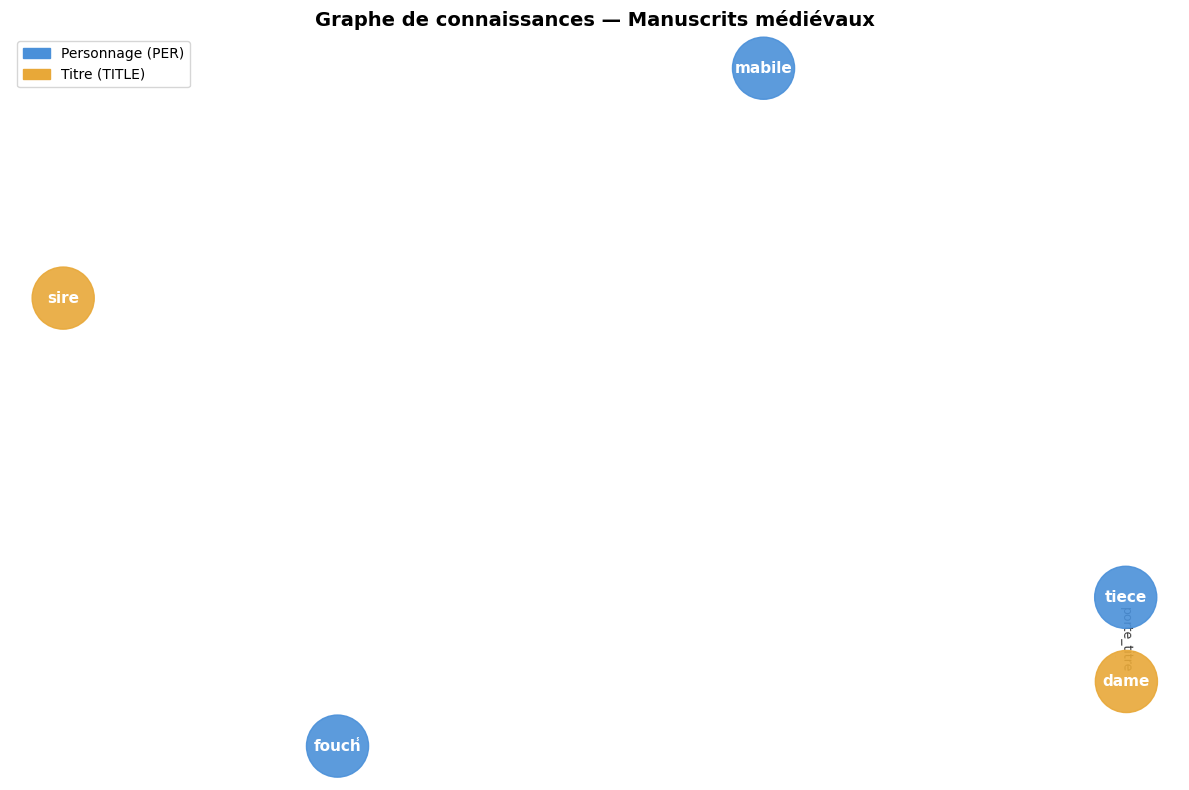

✅ Graphe sauvegardé dans le Drive


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Affichage du graphe
fig, ax = plt.subplots(figsize=(12, 8))

# Positions des noeuds
pos = nx.spring_layout(G, seed=42)

# Couleurs par type d'entité
couleurs = []
for node in G.nodes():
    t = G.nodes[node]["type"]
    if t == "PER":
        couleurs.append("#4A90D9")
    elif t == "TITLE":
        couleurs.append("#E8A838")
    elif t == "LOC":
        couleurs.append("#5CB85C")
    else:
        couleurs.append("#D9534F")

# Labels lisibles
labels = {node: G.nodes[node]["label"] for node in G.nodes()}

# Dessin
nx.draw_networkx_nodes(G, pos, node_color=couleurs, node_size=2000, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, labels, font_size=11, font_color="white", font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="#555555", arrows=True,
                       arrowsize=20, width=2, connectionstyle="arc3,rad=0.1", ax=ax)

edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=9, font_color="#333333", ax=ax)

ax.set_title("Graphe de connaissances — Manuscrits médiévaux", fontsize=14, fontweight="bold")
ax.axis("off")

legende = [
    mpatches.Patch(color="#4A90D9", label="Personnage (PER)"),
    mpatches.Patch(color="#E8A838", label="Titre (TITLE)"),
]
ax.legend(handles=legende, loc="upper left", fontsize=10)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/projet_HTR/graphe_connaissances.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphe sauvegardé dans le Drive")

In [ ]:
import json

triplets_valides = [
    {
        "sujet": "tiece", "relation": "porte_titre", "objet": "dame",
        "confiance": 0.85, "method": "gazetteer",
        "source_line": "btv1b55013464t_f143_z65", "correct": True
    }
]

with open("/content/drive/MyDrive/projet_HTR/triplets_a_valider.json", "w", encoding="utf-8") as f:
    json.dump(triplets_valides, f, indent=2, ensure_ascii=False)

compute_extraction_precision(
    validated_path="/content/drive/MyDrive/projet_HTR/triplets_a_valider.json",
    output_path="/content/drive/MyDrive/projet_HTR/precision_report.json"
)

✅ Livrable : /content/drive/MyDrive/projet_HTR/precision_report.json
   Précision globale (sur 1 triplets validés) : 100 %


{'n_evalues': 1,
 'n_total_echantillon': 1,
 'precision_globale': 1.0,
 'precision_par_relation': {'porte_titre': 1.0}}